# 14. Segment Anything Model (SAM 3.1 / SAM 2 / SAM) Experiments
The **Segment Anything Model (SAM)** is a foundation vision model for promptable, zero-shot image segmentation.

In this notebook, we explore SAM for fashion item detection and segmentation:
1. **Model Initialization**: Load SAM (`facebook/sam-vit-base` or `facebook/sam2.1-hiera-small`) via Hugging Face `transformers`.
2. **Box-Prompted Segmentation**: Supply bounding box prompts (e.g. coarse proposals from Stage 1 detectors) to generate pixel-accurate segmentation masks.
3. **Point-Prompted Segmentation**: Pass interactive 2D point prompts `(x, y)` to segment targeted garment or accessory regions.
4. **Automatic Grid Instance Segmentation**: Generate zero-shot masks across an image grid.
5. **Visualization**: Render interactive HTML overlays with bounding boxes, confidence scores, and segmentation masks.



In [1]:
import os
import sys
import numpy as np
from PIL import Image
from IPython.display import HTML

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.sam import SamDetector
from fashion_detector.utils import load_image, generate_interactive_html

# Load configuration
config = Config("config/config.yaml")

# Initialize SAM Detector
detector = SamDetector(config)
detector.load_model()

/Users/sunnyraj/code_files/git_repos/image-segments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-07-22 19:32:15] [INFO] [fashion_detector:config.py:166] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-22 19:32:15] [INFO] [fashion_detector:sam.py:58] - Loading SAM model: facebook/sam2.1-hiera-small on device: mps


Loading weights: 100%|██████████| 357/357 [00:00<00:00, 8639.07it/s]


[2026-07-22 19:32:21] [INFO] [fashion_detector:sam.py:203] - SAM model loaded successfully.


## 1. Box-Prompted Segmentation
Supply candidate bounding boxes `[xmin, ymin, xmax, ymax]` and target category queries to SAM.
SAM refines the bounding box boundaries and extracts pixel-level binary masks.



In [2]:
image_path = "image.png" if os.path.exists("image.png") else "data/fashion_model_street.jpg"
image = load_image(image_path)
w, h = image.size

# Candidate bounding box prompts scaled to image dimensions
prompt_boxes = [
    [int(w * 0.28), int(h * 0.14), int(w * 0.72), int(h * 0.32)],  # Upper garment / jacket area
    [int(w * 0.30), int(h * 0.33), int(w * 0.70), int(h * 0.76)]   # Lower garment / pants area
]
labels = ["jacket", "pants"]

# Run SAM box-prompted detection
detections = detector.detect(image, input_boxes=prompt_boxes, queries=labels)

print(f"SAM Box-Prompted Detections: {len(detections)}")
for det in detections:
    mask_str = f"shape={det.mask.shape}" if det.mask is not None else "None"
    print(f"- Label: '{det.label}', Score: {det.score:.3f}, Box: {list(map(int, det.box))}, Mask: {mask_str}")



[2026-07-22 18:54:10] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: data/fashion_model_street.jpg
[2026-07-22 18:54:10] [INFO] [fashion_detector:logging.py:98] - Starting: SAM Inference
[2026-07-22 18:54:10] [INFO] [fashion_detector:sam.py:580] - SAM detected/segmented 2 items.
[2026-07-22 18:54:10] [INFO] [fashion_detector:logging.py:103] - Completed: SAM Inference in 0.4720 seconds
SAM Box-Prompted Detections: 2
- Label: 'jacket', Score: 0.968, Box: [265, 144, 534, 391], Mask: shape=(1107, 800)
- Label: 'pants', Score: 0.893, Box: [283, 379, 578, 906], Mask: shape=(1107, 800)


## 2. Render Interactive Visualization
Render an interactive HTML overlay displaying SAM bounding boxes and labels.




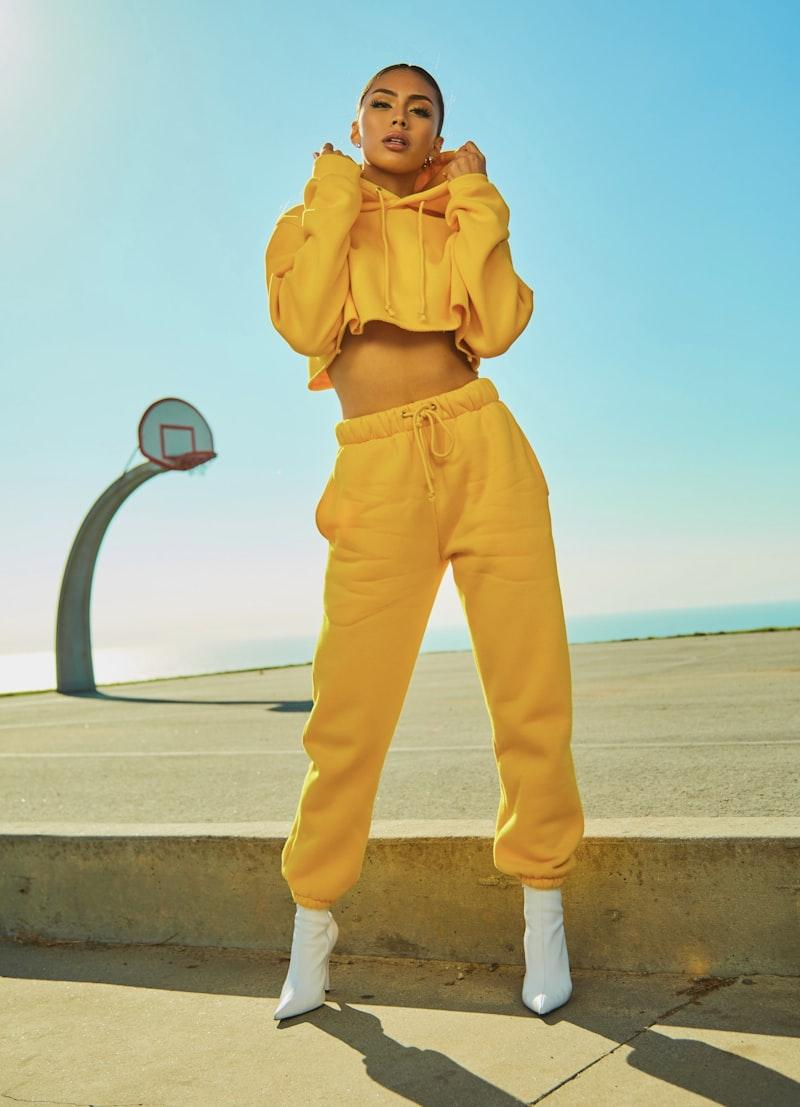

In [3]:
html_str = generate_interactive_html(
    image,
    detections,
    title="SAM Box-Prompted Fashion Item Segmentation"
)
HTML(html_str)



## 3. Point-Prompted Segmentation
Supply 2D point coordinates `[x, y]` to prompt SAM on specific visual keypoints.



In [4]:
img_w, img_h = image.size

# Sample point prompts near center of key fashion regions
point_prompts = [
    [img_w // 2, img_h // 4],     # Upper body point
    [img_w // 2, 2 * img_h // 3]   # Lower body point
]

point_detections = detector.detect(image, input_points=point_prompts, pred_iou_thresh=0.75)

print(f"SAM Point-Prompted Detections: {len(point_detections)}")
for det in point_detections:
    print(f"- Label: '{det.label}', Score: {det.score:.3f}, Box: {list(map(int, det.box))}")



[2026-07-22 18:54:10] [INFO] [fashion_detector:logging.py:98] - Starting: SAM Inference
[2026-07-22 18:54:11] [INFO] [fashion_detector:sam.py:580] - SAM detected/segmented 0 items.
[2026-07-22 18:54:11] [INFO] [fashion_detector:logging.py:103] - Completed: SAM Inference in 0.3572 seconds
SAM Point-Prompted Detections: 0


## 4. Automatic Zero-Shot Grid Segmentation
Generate segmentation masks automatically across an image grid using `points_per_side`.



In [5]:
# Run automatic grid segmentation
auto_detections = detector.detect(
    image,
    points_per_side=16,
    pred_iou_thresh=0.82,
    remove_small_boxes=True
)

print(f"SAM Automatic Grid Segmentation detected {len(auto_detections)} item masks.")



[2026-07-22 18:54:11] [INFO] [fashion_detector:logging.py:98] - Starting: SAM Inference
[2026-07-22 18:54:16] [INFO] [fashion_detector:sam.py:580] - SAM detected/segmented 10 items.
[2026-07-22 18:54:16] [INFO] [fashion_detector:logging.py:103] - Completed: SAM Inference in 5.3478 seconds
SAM Automatic Grid Segmentation detected 10 item masks.


## 5. Native Segmented Class Image Extraction (SAM 3.1)
Extract pixel-isolated RGBA PIL Images (transparent background) for each class natively using `segment_classes()` or `extract_segmented_objects()`.



[2026-07-22 18:54:16] [INFO] [fashion_detector:logging.py:98] - Starting: SAM Segmented Objects Extraction
[2026-07-22 18:54:16] [INFO] [fashion_detector:logging.py:98] - Starting: SAM Inference
[2026-07-22 18:54:16] [INFO] [fashion_detector:sam.py:580] - SAM detected/segmented 2 items.
[2026-07-22 18:54:16] [INFO] [fashion_detector:logging.py:103] - Completed: SAM Inference in 0.3432 seconds
[2026-07-22 18:54:16] [INFO] [fashion_detector:sam.py:667] - SAM extracted 2 isolated segmented object images.
[2026-07-22 18:54:16] [INFO] [fashion_detector:logging.py:103] - Completed: SAM Segmented Objects Extraction in 0.3691 seconds
Extracted 1 isolated segmented image(s) for class 'jacket':
  - Crop 1: dimensions=(279, 257), mode=RGBA
Extracted 1 isolated segmented image(s) for class 'pants':
  - Crop 1: dimensions=(305, 537), mode=RGBA


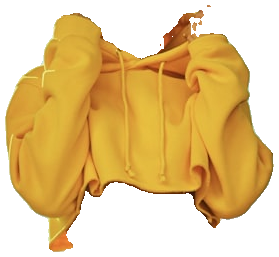

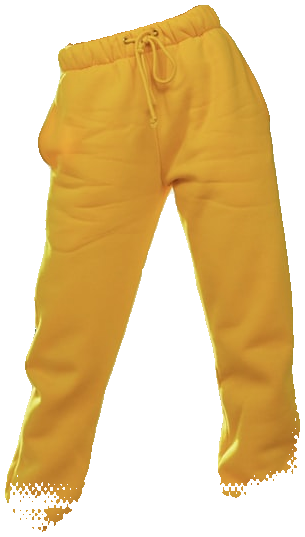

In [6]:
# Extract isolated transparent PNG crops per class
class_crops = detector.segment_classes(
    image,
    user_categories=["jacket", "pants"],
    boxes=prompt_boxes
)

for label, crop_list in class_crops.items():
    print(f"Extracted {len(crop_list)} isolated segmented image(s) for class '{label}':")
    for idx, crop in enumerate(crop_list):
        print(f"  - Crop {idx+1}: dimensions={crop.size}, mode={crop.mode}")

# Display isolated transparent PNG crop for first item
if "jacket" in class_crops and len(class_crops["jacket"]) > 0:
    display(class_crops["jacket"][0])
if "pants" in class_crops and len(class_crops["pants"]) > 0:
    display(class_crops["pants"][0])



## 6. Summary & Key Takeaways
- **SAM 3.1 Architecture**: Utilizes `facebook/sam2.1-hiera-small` for fast, state-of-the-art segmentation.
- **Native Class Segmentation**: `segment_classes()` and `extract_segmented_objects()` produce clean, transparent RGBA PNG crops for every detected item.
- **Stage 2 Synergy**: Candidate proposals from Stage 1 (e.g. YOLO, Grounding DINO) can be passed directly as box prompts to SAM 3 for background suppression and clean mask extraction.
- **Flexibility**: Supports box prompts, point prompts, and automatic grid generation.



In [8]:
from fashion_detector.models.sam3_segmenter import Sam3Segmenter                                                                      
                                                                                                                                          
# Initialize Native SAM 3 Segmenter                                                                                                   
segmenter = Sam3Segmenter(model_name="facebook/sam3.1")                                                                   
segmenter.load_model()                                                                                                                
                                                                                                                                        
# Run Native SAM 3 Promptable Concept Segmentation                                                                                    
result = segmenter.segment_products(                                                                                                  
    image=image,                                                                                                                      
    categories=["dress", "watch", "hat", "sweater", "jacket", "pants"]                                                                
)                                                                                                                                     
                                                                                                                                        
# Access discovered products cleanly by category                                                                                      
for category in result.categories:                                                                                                    
    print(f"Category '{category.label}': {len(category.products)} discovered product instance(s)")                                    
    for product in category.products:                                                                                                 
        display(product.crop)  # Displays pixel-accurate transparent RGBA crop                                                        
                                                                                                                                        
# Save extracted product crops organized by category                                                                                  
# segmenter.save_segments(result, output_dir="sam3_pcs_native_outputs") 

[2026-07-22 19:29:44] [INFO] [fashion_detector:logging.py:98] - Starting: SAM 3 Model Loading
[2026-07-22 19:29:44] [INFO] [fashion_detector.models.sam3_segmenter:sam3_segmenter.py:134] - Loading SAM 3 model: facebook/sam3.1 on device: cpu
[2026-07-22 19:29:44] [INFO] [fashion_detector.models.sam3_segmenter:sam3_segmenter.py:134] - Loading SAM 3 model: facebook/sam3.1 on device: cpu


[transformers] You are using a model of type `sam3_video` to instantiate a model of type `sam`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[2026-07-22 19:30:01] [ERROR] [fashion_detector.models.sam3_segmenter:sam3_segmenter.py:173] - Failed to load SAM 3 model 'facebook/sam3.1': facebook/sam3.1 does not appear to have a file named pytorch_model.bin or model.safetensors.
[2026-07-22 19:30:01] [ERROR] [fashion_detector.models.sam3_segmenter:sam3_segmenter.py:173] - Failed to load SAM 3 model 'facebook/sam3.1': facebook/sam3.1 does not appear to have a file named pytorch_model.bin or model.safetensors.
[2026-07-22 19:30:01] [INFO] [fashion_detector:logging.py:103] - Completed: SAM 3 Model Loading in 16.4385 seconds


OSError: facebook/sam3.1 does not appear to have a file named pytorch_model.bin or model.safetensors.